In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.1 MB/s eta 0:00:00


In [ ]:
# =================================================
# Step 1 :- Libraries
# =================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# =================================================
# Step 2 :- Load Dataset
# =================================================

# File path
file_path = '/content/drive/MyDrive/GitHub/4_Machine_Learning/3. Supervised Learning/1_Linear_Regression/Delhi house data.csv'

# Load the dataset
df = pd.read_csv(file_path)

In [ ]:
# =================================================
# Step 3 :- Information about dataset
# =================================================

In [ ]:
df.shape

(1259, 11)

In [ ]:
df. head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   object 
 4   Locality     1259 non-null   object 
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   object 
 8   Transaction  1259 non-null   object 
 9   Type         1254 non-null   object 
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 108.3+ KB


In [ ]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [ ]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price',
       'Status', 'Transaction', 'Type', 'Per_Sqft'],
      dtype='object')

In [ ]:
# =================================================
# Step 4 :- Dataset Understanding
# =================================================
'''
| ----------------| ------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------- |
| Name of Feature | Description                                                   | Type                     | Relevance                                                                                |
| --------------- | ------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------- |
| Area            | Total area of the property (in square feet)                   | Quantitative, Continuous | Highly relevant, larger area generally increases house price                             |
| BHK             | Number of Bedrooms, Hall, and Kitchen                         | Quantitative, Discrete   | Highly relevant, indicates house size and capacity                                       |
| Bathroom        | Number of bathrooms in the house                              | Quantitative, Discrete   | Relevant, more bathrooms usually increase property value                                 |
| Furnishing      | Furnishing status (Unfurnished, Semi-Furnished, Furnished)    | Qualitative, Nominal     | Relevant, furnished houses are generally priced higher                                   |
| Locality        | Location/Area where the property is situated                  | Qualitative, Nominal     | Highly relevant, locality significantly affects house price                              |
| Parking         | Number of parking spaces available                            | Quantitative, Discrete   | Relevant, additional parking increases property value                                    |
| Price           | Selling price of the property (Target Variable)               | Quantitative, Continuous | Target variable to be predicted                                                          |
| Status          | Construction status (Ready to Move, Under Construction, etc.) | Qualitative, Nominal     | Relevant, completed properties often have higher demand                                  |
| Transaction     | Type of sale (New Property or Resale)                         | Qualitative, Nominal     | Relevant, resale and new properties may have different prices                            |
| Type            | Type of property (Apartment, Builder Floor, etc.)             | Qualitative, Nominal     | Relevant, different property types have different market values                          |
| Per_Sqft        | Price per square foot                                         | Quantitative, Continuous | Relevant, useful for market comparison and price analysis (contains many missing values) |
| --------------- | ------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------- |
'''

'\n| ----------------| ------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------- |\n| Name of Feature | Description                                                   | Type                     | Relevance                                                                                |\n| --------------- | ------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------- |\n| Area            | Total area of the property (in square feet)                   | Quantitative, Continuous | Highly relevant, larger area generally increases house price                             |\n| BHK             | Number of Bedrooms, Hall, and Kitchen                         | Quantitative, Discrete   | Highly relevant, indicates house size and capacity                        

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'BHK'}>],
       [<Axes: title={'center': 'Bathroom'}>,
        <Axes: title={'center': 'Parking'}>],
       [<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Per_Sqft'}>]], dtype=object)

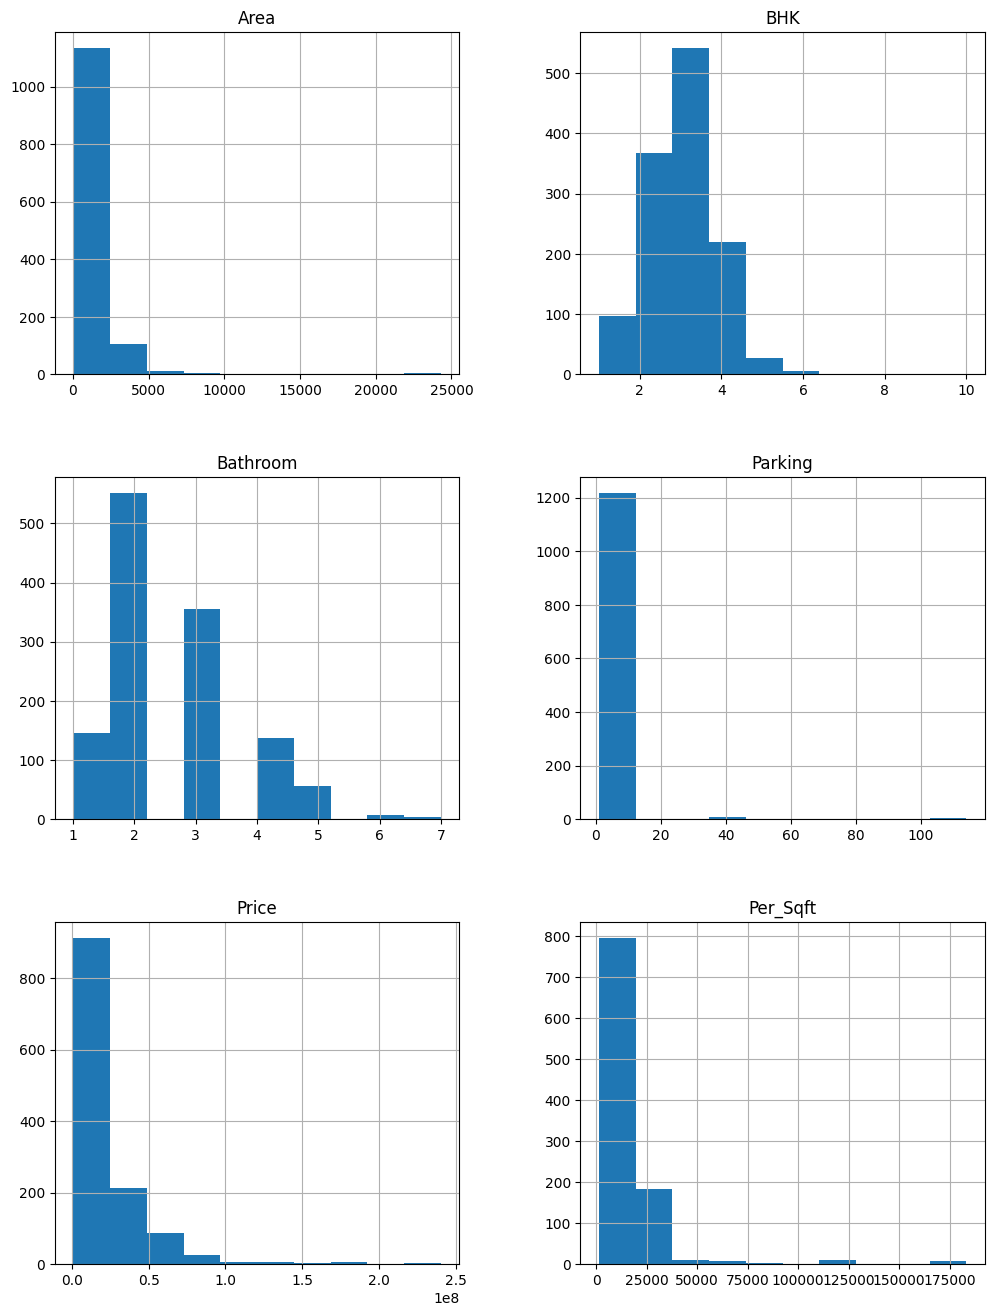

In [ ]:
# =================================================
# Step 5 :- EDA
# =================================================

df.hist(figsize = (12, 16))

<Axes: >

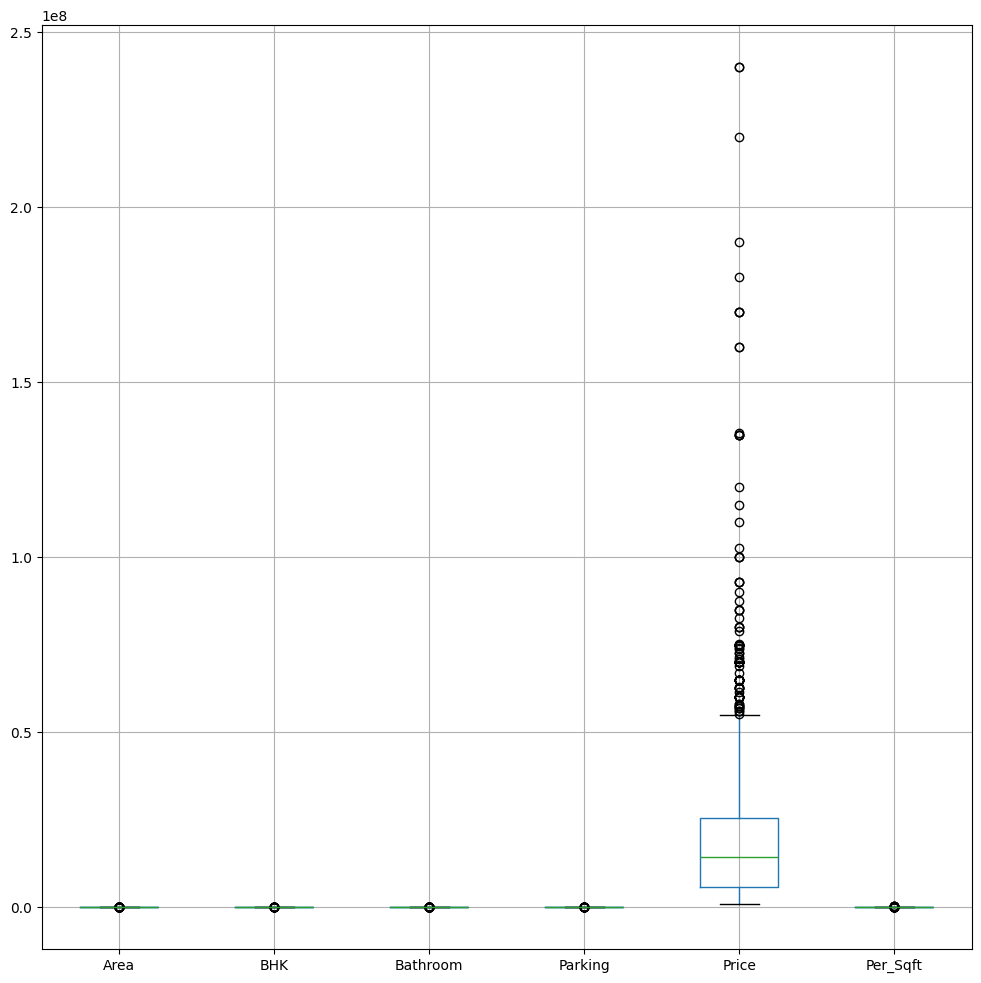

In [ ]:
from pandas.plotting import boxplot
df.boxplot(figsize = (12, 12))

In [ ]:
# Categorical Variable
cat_var = df.select_dtypes(include=object).columns.tolist()
cat_var.remove('Locality')
print(cat_var)

# Numerical Variable
num_var = df.select_dtypes(include=np.number).columns.tolist()
print(num_var)

['Furnishing', 'Status', 'Transaction', 'Type']
['Area', 'BHK', 'Bathroom', 'Parking', 'Price', 'Per_Sqft']


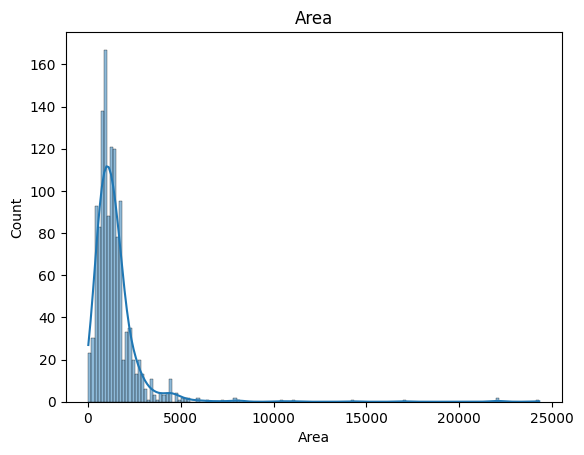

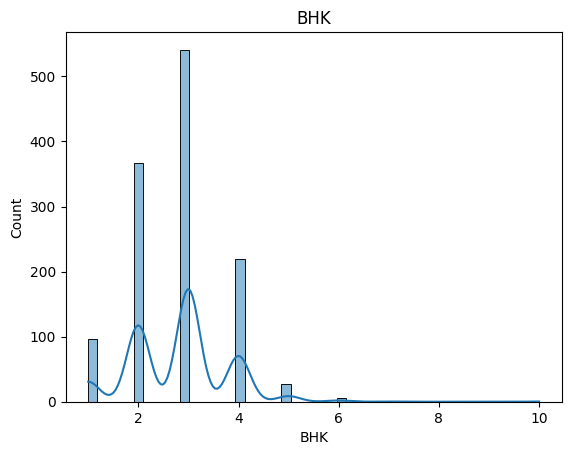

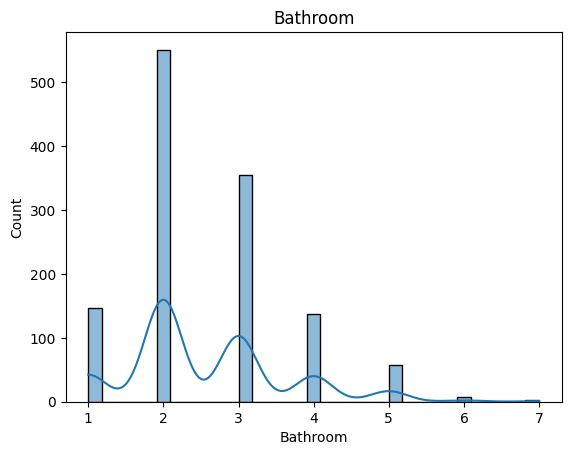

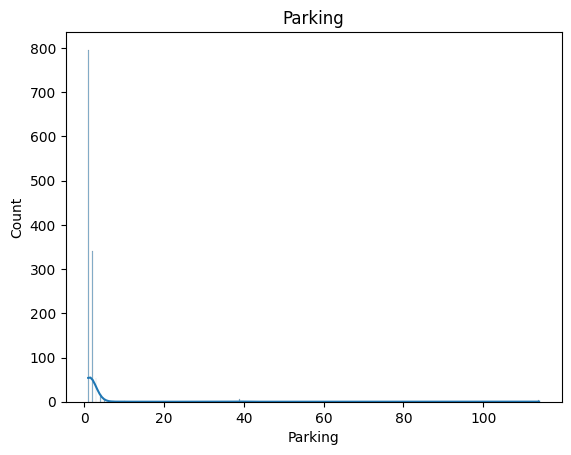

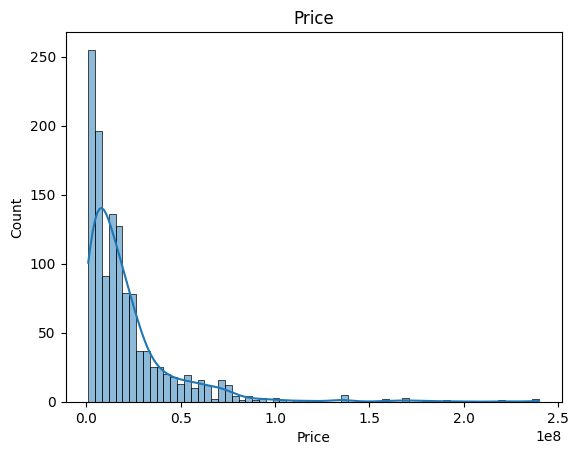

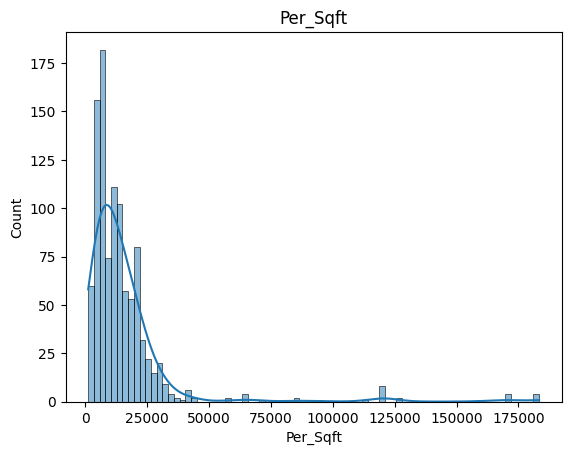

In [ ]:
for col in num_var:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

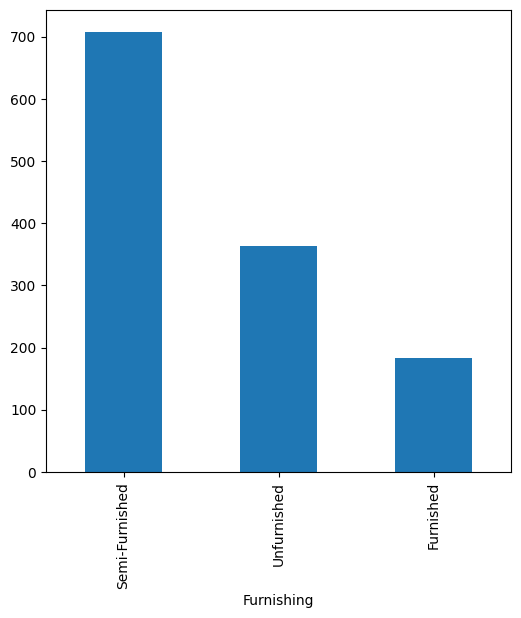

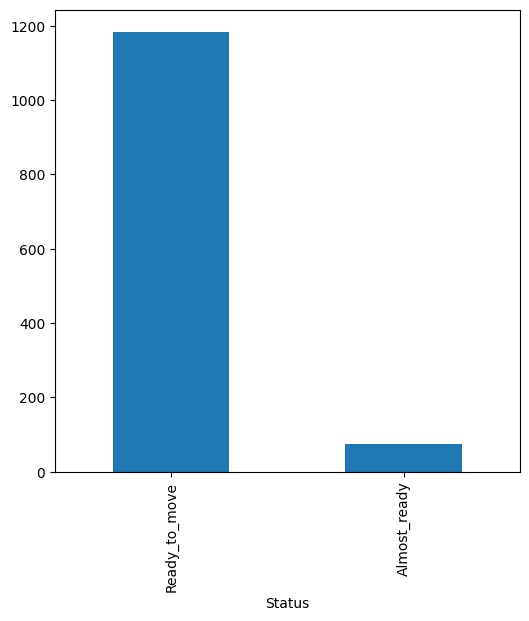

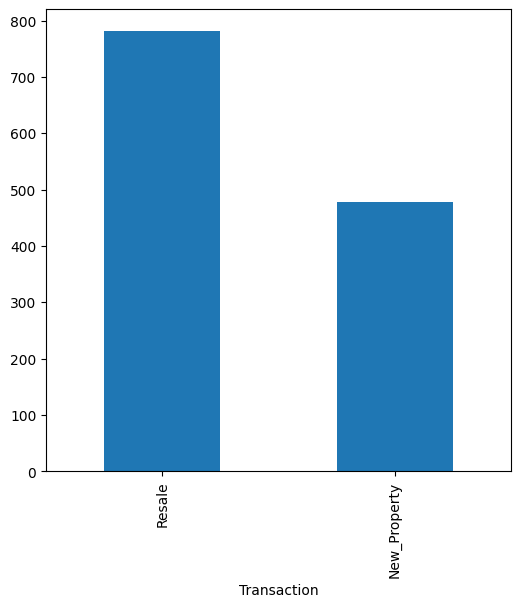

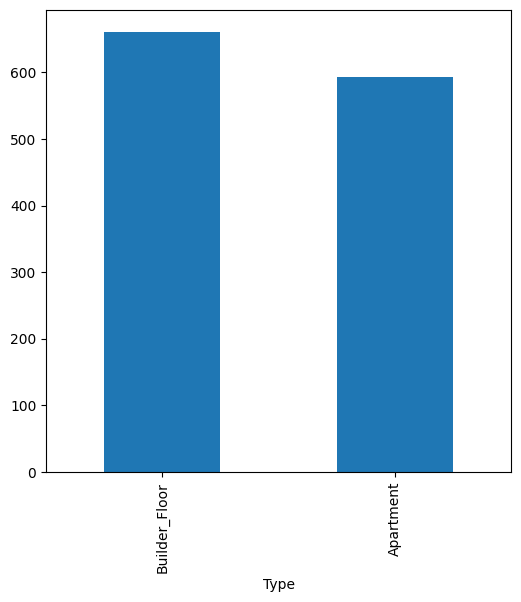

In [ ]:
for col in cat_var:
    plt.figure(figsize = (6, 6))
    df[col].value_counts().plot(kind = 'bar')
    # plt.title(col)
    plt.show()

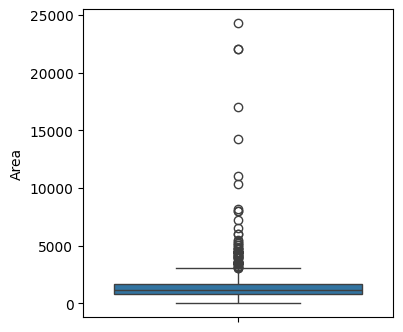

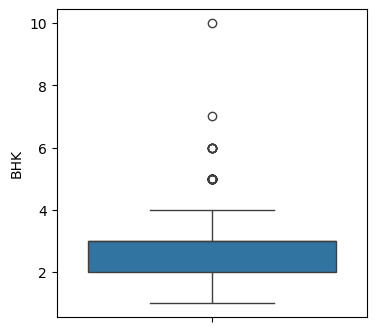

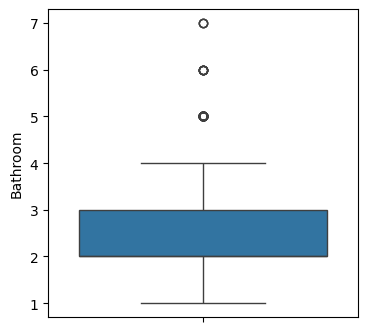

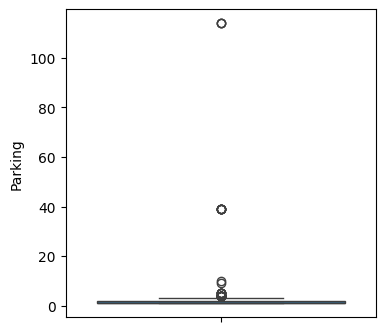

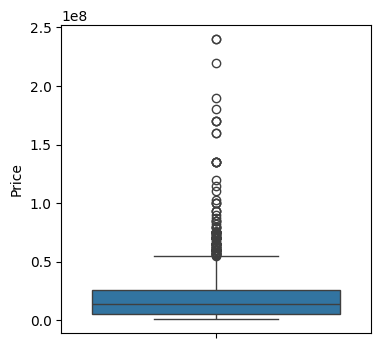

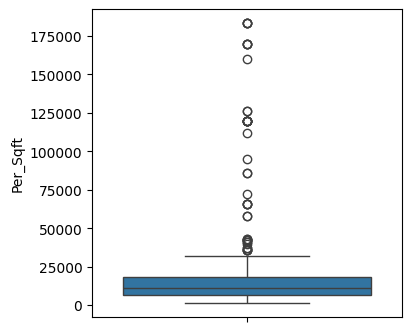

In [ ]:
for col in num_var:
    plt.figure(figsize = (4, 4))
    sns.boxplot(df[col])
    plt.show()

In [ ]:
for col in num_var:
    # Drop missing values
    data = df[col].dropna()

    # Calculate Q1, Q3, and IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    count = len(outliers)

    print(f"{col:<15} : {count}")

Area            : 67
BHK             : 35
Bathroom        : 67
Parking         : 35
Price           : 104
Per_Sqft        : 45


In [ ]:
# Skewness Calculation
for col in num_var:
    print(f" {col} : ", df[col].skew())

 Area :  8.07515616281071
 BHK :  0.5307968884909338
 Bathroom :  0.8332073885307053
 Parking :  15.12306646361345
 Price :  3.4985293780254785
 Per_Sqft :  5.336102957590786


In [ ]:
'''
| ------------ | ----------------------- | ----------- | -------------------- | ------------------------------------------------------------------------------------------------------------ |
| Feature      | Distribution            | Skewness    | Outliers Present     | Interpretation                                                                                               |
| ------------ | ----------------------- | ----------- | -------------------- | ------------------------------------------------------------------------------------------------------------ |
| Area         | Highly Right Skewed     | 8.08        | Yes (67)             | Most houses have moderate area, while a few very large properties create a long right tail.                  |
| BHK          | Slightly Right Skewed   | 0.53        | Yes (35)             | Most properties have 2–3 BHK, with fewer high-BHK luxury houses.                                             |
| Bathroom     | Moderately Right Skewed | 0.83        | Yes (67)             | Most houses have 2–3 bathrooms, while luxury homes with many bathrooms appear as outliers.                   |
| Parking      | Highly Right Skewed     | 15.32       | Yes (35)             | Majority of houses have 1–2 parking spaces, while a few premium houses have unusually high parking capacity. |
| Price        | Highly Right Skewed     | 3.50        | Yes (104)            | Most houses are moderately priced, whereas luxury properties have extremely high prices, creating outliers.  |
| Per_Sqft     | Highly Right Skewed     | 5.93        | Yes (45)             | Most properties have average price per square foot, while premium localities have exceptionally high values. |
| ------------ | ----------------------- | ----------- | -------------------- | ------------------------------------------------------------------------------------------------------------ |
'''

'\n| ------------ | ----------------------- | ----------- | -------------------- | ------------------------------------------------------------------------------------------------------------ |\n| Feature      | Distribution            | Skewness    | Outliers Present     | Interpretation                                                                                               |\n| ------------ | ----------------------- | ----------- | -------------------- | ------------------------------------------------------------------------------------------------------------ |\n| Area         | Highly Right Skewed     | 8.08        | Yes (67)             | Most houses have moderate area, while a few very large properties create a long right tail.                  |\n| BHK          | Slightly Right Skewed   | 0.53        | Yes (35)             | Most properties have 2–3 BHK, with fewer high-BHK luxury houses.                                             |\n| Bathroom     | Moderately Right Ske

In [ ]:
# =================================================
# Step 6 :- Feature Engineering
# =================================================

# Checking Null Values in Dataset
df.isnull().sum()

,0
Area,0
BHK,0
Bathroom,2
Furnishing,5
Locality,0
Parking,33
Price,0
Status,0
Transaction,0
Type,5


In [ ]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [ ]:
# Mean Imputation for numeric feature
df['Bathroom'].fillna(df['Bathroom'].mean(), inplace = True)

df['Per_Sqft'].fillna(df['Per_Sqft'].mean(), inplace = True)

df['Parking'].fillna(df['Parking'].mean(), inplace = True)

# Mode Imputation for categorical feature
df['Furnishing'].fillna(df['Furnishing'].mode()[0], inplace = True)

df['Type'].fillna(df['Type'].mode()[0], inplace = True)

/tmp/ipykernel_330/1761914592.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Bathroom'].fillna(df['Bathroom'].mean(), inplace = True)
/tmp/ipykernel_330/1761914592.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [ ]:
df.isnull().sum()

,0
Area,0
BHK,0
Bathroom,0
Furnishing,0
Locality,0
Parking,0
Price,0
Status,0
Transaction,0
Type,0


In [ ]:
# Saving Cleaned csv
df.to_csv('Cleaned_Delhi_House_Data.csv', index = False)

In [ ]:
# Feature Transformation
'''
| ------------------- | ------------------------------------------------------------------ |
| Feature             | Recommended Action                                                 |
| ------------------- | ------------------------------------------------------------------ |
| Area                | Log Transformation or Yeo-Johnson Transform                        |
| Price               | Log Transformation                                                 |
| Per_Sqft            | Log Transformation                                                 |
| Parking             | Keep as is or apply Yeo-Johnson if needed                          |
| BHK                 | No transformation required                                         |
| Bathroom            | No transformation required                                         |
| ------------------- | ------------------------------------------------------------------ |
'''

'\n| ------------------- | ------------------------------------------------------------------ |\n| Feature             | Recommended Action                                                 |\n| ------------------- | ------------------------------------------------------------------ |\n| Area                | Log Transformation or Yeo-Johnson Transform                        |\n| Price               | Log Transformation                                                 |\n| Per_Sqft            | Log Transformation                                                 |\n| Parking             | Keep as is or apply Yeo-Johnson if needed                          |\n| BHK                 | No transformation required                                         |\n| Bathroom            | No transformation required                                         |\n| ------------------- | ------------------------------------------------------------------ |\n'

In [ ]:
# Applying Log Transformation on Area, Price and Per_Sqft

df['Area'] = np.log1p(df['Area'])

df['Price'] = np.log1p(df['Price'])

df['Per_Sqft'] = np.log1p(df['Per_Sqft'])

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Price'}>],
       [<Axes: title={'center': 'Per_Sqft'}>, <Axes: >]], dtype=object)

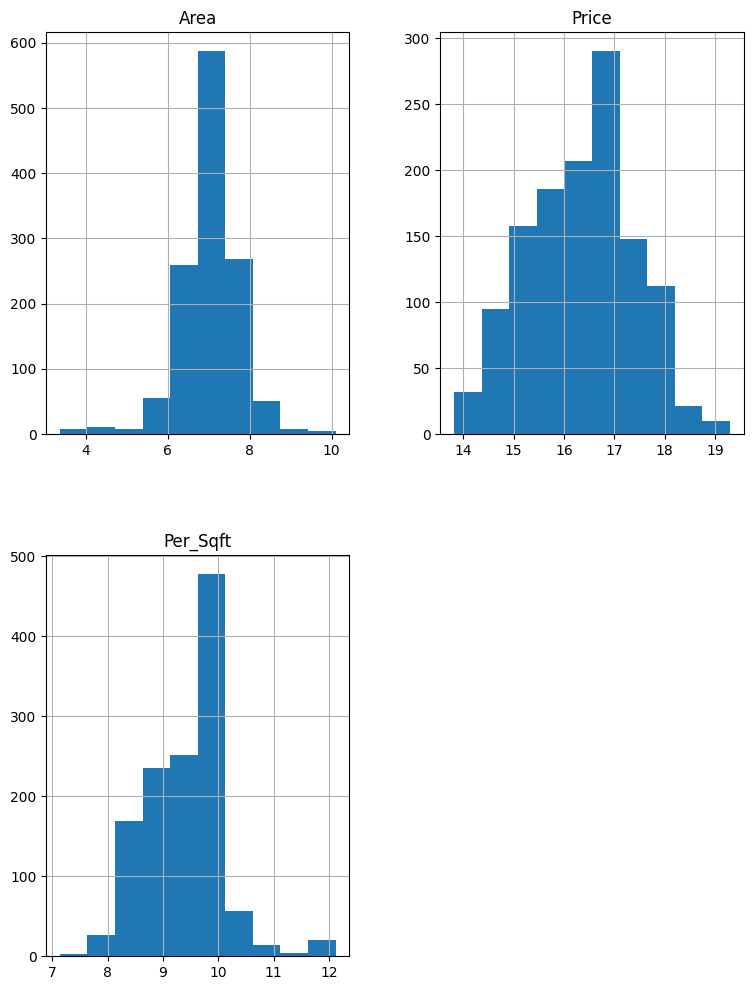

In [ ]:
df[['Area', 'Price', 'Per_Sqft']].hist(figsize = (9, 12))

In [ ]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,6.685861,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,15.687313,Ready_to_move,New_Property,Builder_Floor,9.660851
1,6.621406,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,15.424949,Ready_to_move,New_Property,Apartment,8.805075
2,6.857514,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,16.556351,Ready_to_move,Resale,Apartment,8.805075
3,6.398595,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,15.250595,Ready_to_move,Resale,Builder_Floor,8.805075
4,6.478510,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,15.640060,Ready_to_move,New_Property,Builder_Floor,8.805075


In [ ]:
for col in cat_var:
    print(f"{col} -> {df[col].unique()}")

Furnishing -> ['Semi-Furnished' 'Furnished' 'Unfurnished']
Status -> ['Ready_to_move' 'Almost_ready']
Transaction -> ['New_Property' 'Resale']
Type -> ['Builder_Floor' 'Apartment']


In [ ]:
# Applying Label Encoding for Furnishing, Status, Transaction and Type

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Furnishing'] = encoder.fit_transform(df['Furnishing'])

df['Status'] = encoder.fit_transform(df['Status'])

df['Transaction'] = encoder.fit_transform(df['Transaction'])

df['Type'] = encoder.fit_transform(df['Type'])

In [ ]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,6.685861,3,2.0,1,Rohini Sector 25,1.0,15.687313,1,0,1,9.660851
1,6.621406,2,2.0,1,"J R Designers Floors, Rohini Sector 24",1.0,15.424949,1,0,0,8.805075
2,6.857514,2,2.0,0,"Citizen Apartment, Rohini Sector 13",1.0,16.556351,1,1,0,8.805075
3,6.398595,2,2.0,1,Rohini Sector 24,1.0,15.250595,1,1,1,8.805075
4,6.478510,2,2.0,1,Rohini Sector 24 carpet area 650 sqft status R...,1.0,15.640060,1,0,1,8.805075


In [ ]:
# Applying Target Encoding on Locality

from category_encoders import TargetEncoder

encoder = TargetEncoder()

df['Locality'] = encoder.fit_transform(df['Locality'], df['Price'])

In [ ]:
df['Locality'].head()

,Locality
0,16.236383
1,15.817031
2,16.375273
3,16.254489
4,16.256055


In [ ]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,6.685861,3,2.0,1,16.236383,1.0,15.687313,1,0,1,9.660851
1,6.621406,2,2.0,1,15.817031,1.0,15.424949,1,0,0,8.805075
2,6.857514,2,2.0,0,16.375273,1.0,16.556351,1,1,0,8.805075
3,6.398595,2,2.0,1,16.254489,1.0,15.250595,1,1,1,8.805075
4,6.478510,2,2.0,1,16.256055,1.0,15.640060,1,0,1,8.805075


In [ ]:
# Saving Preprossed File
df.to_csv('Preprocessed_Delhi_House_Data.csv', index = False)

In [ ]:
# =================================================
# Step 7 :- Train-Test Split
# =================================================

from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop('Price', axis = 1)

y = df['Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (1007, 10)
Testing Features  : (252, 10)
Training Target   : (1007,)
Testing Target    : (252,)


In [ ]:
# =================================================
# Step 7 :- Model Training
# =================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# =================================================
# Step 7 :- Evaluation Metrics
# =================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [ ]:
print("Linear Regression Performance")

print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² Score : {r2:.4f}")

Linear Regression Performance
MAE  : 0.33
MSE  : 0.18
RMSE : 0.43
R² Score : 0.8351


In [ ]:
# Comparision
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
76,16.516872,16.137628
1026,17.054189,17.249614
43,15.869634,15.975030
666,17.776324,17.651842
529,14.483340,14.492468
101,17.370859,17.321028
908,17.776324,17.712472
1224,18.515991,17.906230
777,15.319588,15.312639
453,16.733281,16.544969


In [ ]:
# Model Coefficient
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coefficients)

       Feature  Coefficient
0         Area     0.354021
1          BHK     0.158243
2     Bathroom     0.262862
3   Furnishing    -0.028585
4     Locality     1.177894
5      Parking     0.002380
6       Status    -0.106421
7  Transaction    -0.023540
8         Type    -0.126183
9     Per_Sqft     0.225826
